In [20]:
import os
from os import listdir

from os.path import isfile, join, dirname, basename
import pandas as pd

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import matplotlib.gridspec as gridspec

In [23]:
%run analysis_utils.py

In [24]:
def process_and_sort(df):
    model_means = df.groupby('experiment')['mean'].mean().reset_index(name='mean_overall')
    # model_means = df.groupby('experiment')['mean'].median().reset_index(name='mean_overall')

    model_groups = df[['experiment', 'group']].drop_duplicates()

    sorted_models = model_means.merge(model_groups, on='experiment')
    sorted_models = sorted_models.sort_values(by=['group', 'mean_overall'], ascending=[True, False])
    sorted_model_order = sorted_models['experiment'].tolist()

    heatmap_df = df.pivot(index='experiment_name', columns='experiment', values='mean')
    heatmap_df = heatmap_df[sorted_model_order]

    return heatmap_df, sorted_models

In [25]:

def plot_composite_by_group_panels(heatmap_df, sorted_models, metric, clf='avg', save_dir='.'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.gridspec as gridspec
    import numpy as np
    from os.path import join
    from matplotlib.cm import get_cmap
    from matplotlib.colors import Normalize

    sorted_models = sorted_models.round(2)
    heatmap_df = heatmap_df.round(2)

    # Calculate row-wise averages and sort
    row_avg = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.loc[row_avg.sort_values(ascending=False).index]

    grouped = sorted_models.groupby('group')
    n_groups = len(grouped)
    palette = sns.color_palette("husl", n_groups)
    color_map = dict(zip(grouped.groups.keys(), palette))

    global_vmin = heatmap_df.min().min()
    global_vmax = heatmap_df.max().max()
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    cmap = get_cmap('viridis')

    total_models = sum(len(group_df) for _, group_df in grouped)
    fig = plt.figure(figsize=(max(6, total_models * 0.5 + 1.5), max(6, heatmap_df.shape[0] * 0.6)))

    group_model_counts = [len(group_df) for _, group_df in grouped]

    # gs = gridspec.GridSpec(
    #     3,
    #     n_groups + 2,
    #     width_ratios=group_model_counts + [0.2, 1.0],
    #     height_ratios=[1.2, 6, 0.4],
    #     hspace=0.3,
    #     wspace=0.1
    # )

    gs = gridspec.GridSpec(
        3,
        n_groups + 2,  # +2 for row avg and colorbar
        width_ratios=group_model_counts + [1.0, 0.2],  # row avg, colorbar
        height_ratios=[1.2, 6, 0.4],
        hspace=0.3,
        wspace=0.1
    )
        
    for i, (group_name, group_df) in enumerate(grouped):
        # cbar = (i == n_groups - 1)
        # cbar_ax = fig.add_subplot(gs[1, -2]) if cbar else None

        cbar = (i == n_groups - 1)
        cbar_ax = fig.add_subplot(gs[1, -1]) if cbar else None  # now last column
        
        color = color_map[group_name]
        model_names = group_df['experiment'].tolist()
        model_avg = group_df['mean_overall'].tolist()
        group_heatmap = heatmap_df[model_names]

        # Top bar plot
        ax_top = fig.add_subplot(gs[0, i])
        bars = ax_top.bar(range(len(model_avg)), model_avg, color=color)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        # ax_top.set_title(f"{group_name}\nAvg {metric}", fontsize=6)
        ax_top.set_ylim(0.7, 1)

        # Remove all spines (bounding boxes)
        for spine in ax_top.spines.values():
            spine.set_visible(False)

        for idx, bar in enumerate(bars):
            height = bar.get_height()
            ax_top.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2f}", ha='center', va='bottom', fontsize=6)

        # Heatmap
        ax_heatmap = fig.add_subplot(gs[1, i])
        sns.heatmap(
            group_heatmap,
            ax=ax_heatmap,
            annot=False,
            fmt=".2f",
            cmap='viridis',
            vmin=global_vmin,
            vmax=global_vmax,
            cbar=cbar,
            cbar_ax=cbar_ax,
            xticklabels=False,
            annot_kws={"size": 6}
        )
        ax_heatmap.set_xticklabels([])
        ax_heatmap.tick_params(axis='x', bottom=False)
        ax_heatmap.set_xlabel(group_name)
        if i != 0:
            ax_heatmap.set_ylabel("")
            ax_heatmap.set_yticks([])
            ax_heatmap.set_yticklabels([])

        xticklabels = model_names
        ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8)
        ax_heatmap.set_ylabel('')

        # Bottom color bar
        ax_bottom = fig.add_subplot(gs[2, i])
        for j in range(len(model_names)):
            ax_bottom.add_patch(plt.Rectangle((j, 0), 1, 1, color=color))
            
        ax_bottom.set_xlim(0, len(model_names))
        ax_bottom.set_ylim(0, 1)
        ax_bottom.axis('off')
        for j, model in enumerate(model_names):
            ax_bottom.text(j + 0.5, -0.2, model, ha='right', va='top', rotation=90, fontsize=10, rotation_mode='anchor')

     # Right-side bar plot: row average
    # ax_right_bar = fig.add_subplot(gs[1, -1])
    # avg_vals = heatmap_df.mean(axis=1)
    # y_positions = np.arange(len(avg_vals))
    
    # Right-side bar plot: row average (now second-to-last column)
    ax_right_bar = fig.add_subplot(gs[1, -2])
    avg_vals = heatmap_df.mean(axis=1)
    y_positions = np.arange(len(avg_vals))
    colors = [cmap(norm(val)) for val in avg_vals]

    ax_right_bar.barh(y_positions, avg_vals.values, color=colors)

    ax_right_bar.invert_yaxis()  # Align with heatmap rows
    ax_right_bar.set_xlim(0.4, 1.0)
    ax_right_bar.set_yticks([])
    ax_right_bar.set_xticks([])
    ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=5)

    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)
        

    # Use heatmap order and colormap for coloring
    colors = [cmap(norm(val)) for val in avg_vals]

    bars = ax_right_bar.barh(y_positions, avg_vals.values, color=colors)
    
    if cbar_ax is not None:
        cbar_ax.tick_params(labelsize=6)  # Control colorbar tick font size here

    # Align and remove ticks
    # ax_right_bar.invert_yaxis()  # Align top-down with heatmap
    # ax_right_bar.set_xlim(0.7, 1.0)
    # ax_right_bar.set_yticks([])
    # ax_right_bar.set_xticks([])
    # ax_right_bar.set_xlabel(f"Avg {metric}", fontsize=8)

    # Remove border/spines
    for spine in ax_right_bar.spines.values():
        spine.set_visible(False)

    # Group legend (optional)
    fig.subplots_adjust(bottom=0.25)
    legend_handles = [plt.Line2D([0], [0], color=c, lw=10) for c in color_map.values()]
    # fig.legend(legend_handles, color_map.keys(), loc='lower center', ncol=n_groups)

    output_path = join(save_dir, f'{metric}_{clf}.png')
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Grouped panel heatmap saved to {output_path}")
    return fig

In [26]:
metrics= ['AUC', 'F1', 'AUPRC', 'Recall', 'Precision', 'Accuracy']

In [27]:
clfs = ['vote', 'mil', 'avg'] #['avg', 'mil']

In [28]:
test_df = pd.read_csv('results/classification_metrcis.csv')

In [29]:
test_df

,Unnamed: 0,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,strategy,group
0,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,HVG,Treatment Naive vs TKI treated,vote,Baseline
1,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,HVG,Treatment Naive vs TKI treated,vote,Baseline
2,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,HVG,Treatment Naive vs TKI treated,vote,Baseline
3,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,HVG,Treatment Naive vs TKI treated,vote,Baseline
4,4,0.888889,0.933333,0.833333,0.828571,0.875000,0.833333,HVG,MMRd vs MMRp,vote,Baseline
...,...,...,...,...,...,...,...,...,...,...,...
1408,470,0.714286,0.333333,0.875000,0.466667,0.437500,0.500000,Nicheformer,Treatment Naive vs Neoadjuvant Chemo,avg,Other
1409,471,0.666667,0.450000,0.750000,0.666667,0.666667,0.666667,Nicheformer,Treatment Naive vs Neoadjuvant Chemo,avg,Other
1410,472,1.000000,1.000000,0.750000,0.428571,0.375000,0.500000,Nicheformer,Treatment Naive vs Neoadjuvant Chemo,avg,Other
1411,473,0.833333,0.750000,0.875000,0.794872,0.928571,0.750000,Nicheformer,Treatment Naive vs Neoadjuvant Chemo,avg,Other


In [30]:
'experiment_name', 'experiment', 'group', 'mean'

('experiment_name', 'experiment', 'group', 'mean')

In [31]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]

In [32]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'avg']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,HVG,scVI,PCA [100],GF-V2-Deep,GF-V2 [cancer],GF-V1,GF-V2,SCimiarity,STATE,scFoundation,Nicheformer,CellPLM,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,,,,,
ER+ vs TNBC,0.983333,1.000000,0.966667,0.956667,0.956667,0.901111,0.901111,0.956667,0.911111,1.000000,0.901111,0.934444,0.956667,0.851111
IO Response,0.950000,0.916667,0.533333,0.866667,0.933333,0.900000,0.933333,0.966667,0.950000,0.866667,0.916667,0.866667,0.916667,0.816667
MMRd vs MMRp,0.937238,0.912626,0.836394,0.888825,0.903365,0.894952,0.828238,0.829921,0.893905,0.823999,0.816975,0.858642,0.676203,0.627909
T-cell exhaustion,0.830000,0.833333,0.531667,0.800000,0.650000,0.606667,0.683333,0.806667,0.646667,0.796667,0.546667,0.790000,0.873333,0.600000
Treatment Naive vs Anti PD1,1.000000,0.995238,0.971712,0.982143,0.983333,0.957937,0.952823,0.952744,1.000000,1.000000,0.922460,0.771801,0.966198,0.895833
Treatment Naive vs Neoadjuvant Chemo,NaN,0.531667,0.491667,0.780000,0.700000,0.716667,0.673333,0.660000,0.683333,0.530000,0.606667,0.416667,0.661905,0.625238
Treatment Naive vs TKI treated,1.000000,0.875000,0.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_520695/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_avg.png


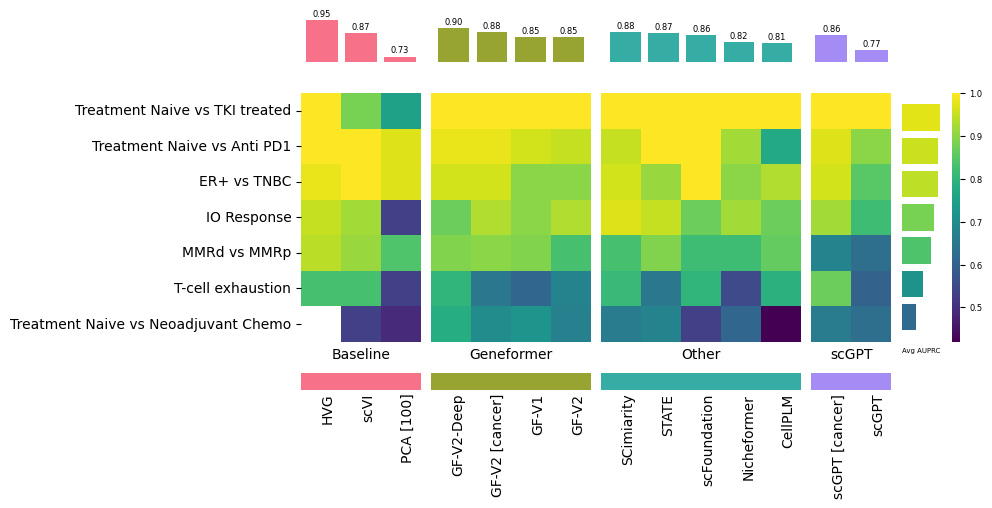

In [33]:
m = 'AUPRC'
clf = 'avg'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [34]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'MIL']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,HVG,PCA [100],scVI,GF-V2,GF-V2 [cancer],GF-V2-Deep,GF-V1,SCimiarity,STATE,scFoundation,CellPLM,Nicheformer,scGPT [cancer],scGPT
experiment_name,,,,,,,,,,,,,,
ER+ vs TNBC,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.983333,1.000000,1.000000,1.000000,1.000000,0.750000,0.966667,0.983333
IO Response,0.866667,0.866667,0.900000,0.950000,0.933333,0.933333,0.833333,0.966667,0.866667,0.950000,1.000000,0.933333,0.916667,0.883333
MMRd vs MMRp,0.887198,0.863476,0.869238,0.828436,0.930889,0.918746,0.802563,0.819706,0.935293,0.825007,0.795316,0.758912,0.572276,0.592944
T-cell exhaustion,0.900000,0.883333,0.866667,0.830000,0.773333,0.866667,0.663333,0.790000,0.900000,0.840000,0.866667,0.660000,0.640000,0.723333
Treatment Naive vs Anti PD1,1.000000,1.000000,1.000000,0.983333,0.986667,1.000000,0.891880,0.983016,1.000000,1.000000,0.872963,0.758106,0.844246,0.656944
Treatment Naive vs Neoadjuvant Chemo,NaN,0.773333,0.673333,0.633333,0.563333,0.466667,0.661905,1.000000,0.716667,0.506667,0.448333,0.491905,0.560714,0.568571
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_520695/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_mil.png


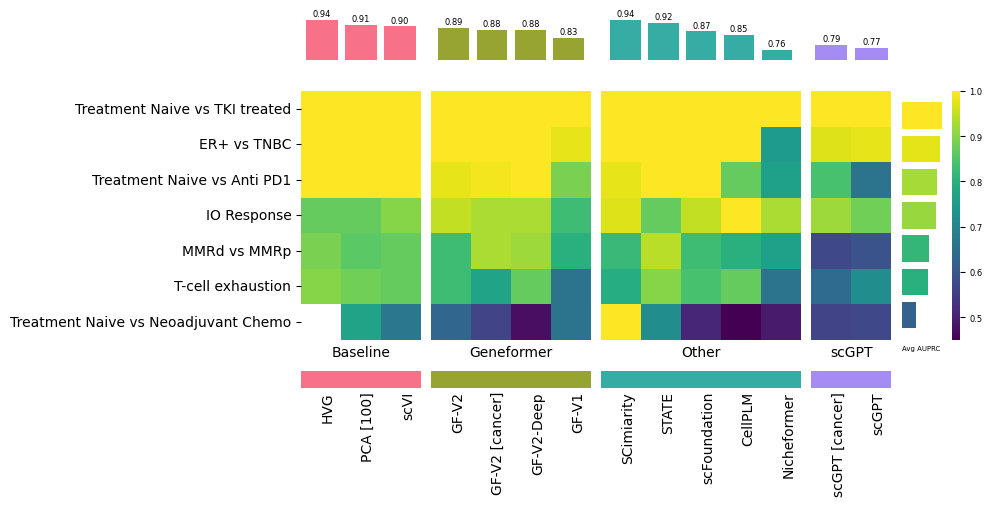

In [35]:
m = 'AUPRC'
clf = 'mil'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [36]:
auprc_df = test_df[['AUPRC', 'model', 'exp', 'group','strategy']]
auprc_df_avg = auprc_df[auprc_df['strategy'] == 'vote']
auprc_df_avg
dd = auprc_df_avg.groupby(['exp', 'group', 'model', 'strategy']).mean().reset_index()
dd['mean'] = dd['AUPRC']
dd['experiment_name'] = dd['exp'] 
dd['experiment'] = dd['model']
heatmap_df_grouped, sorted_models = process_and_sort(dd)
heatmap_df_grouped
# heatmap_df_grouped  = heatmap_df_grouped.drop('luad_cancer_stage', axis=0)

experiment,HVG,scVI,PCA [100],GF-V2-Deep,GF-V2 [cancer],GF-V2,GF-V1,STATE,SCimiarity,scFoundation,CellPLM,Nicheformer,scGPT,scGPT [cancer]
experiment_name,,,,,,,,,,,,,,
ER+ vs TNBC,1.000000,1.000000,1.000000,0.973333,1.000000,0.973333,0.973333,1.000000,1.000000,1.000000,0.940000,0.973333,0.956667,0.983333
IO Response,0.916667,0.950000,0.950000,0.950000,0.966667,0.916667,0.916667,0.950000,0.916667,0.916667,0.900000,0.900000,0.950000,0.950000
MMRd vs MMRp,0.915667,0.925722,0.905571,0.904222,0.896365,0.914778,0.819254,0.922556,0.870444,0.874626,0.830444,0.786595,0.596554,0.596554
T-cell exhaustion,0.783333,0.850000,0.706667,0.790000,0.773333,0.773333,0.773333,0.806667,0.790000,0.723333,0.806667,0.646667,0.763333,0.800000
Treatment Naive vs Anti PD1,1.000000,1.000000,1.000000,0.983333,0.975000,0.975000,0.928941,0.995238,0.983333,1.000000,0.854650,0.806259,0.910801,0.974531
Treatment Naive vs Neoadjuvant Chemo,NaN,0.631667,0.490000,0.480000,0.420000,0.475238,0.513333,0.505000,0.523333,0.401905,0.468571,0.518571,0.613333,0.458571
Treatment Naive vs TKI treated,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


/tmp/ipykernel_520695/114508973.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


Grouped panel heatmap saved to ./plots/AUPRC_vote.png


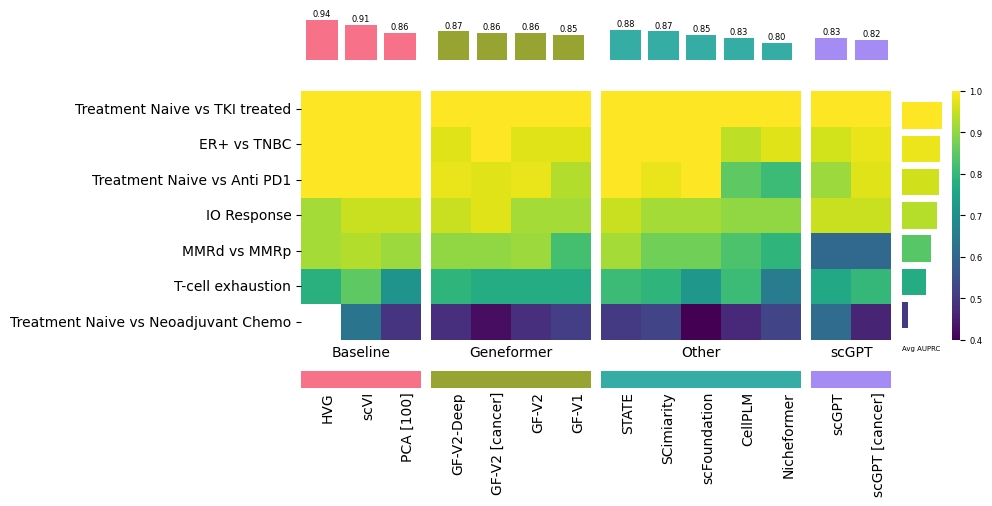

In [37]:
m = 'AUPRC'
clf = 'vote'
plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')

In [38]:
# for clf in clfs:
#     print(clf)
#     for m in metrics:
#         print(m)
#         heatmap_df = collect_auprc_scores(metric=m,clf=clf, base_dir='./metrics')
#         idx = heatmap_df.experiment.str.contains('continue')
#         heatmap_df= heatmap_df[~idx]
#         idx = heatmap_df.experiment.str.contains('freez')
#         heatmap_df= heatmap_df[~idx]
        
#         idx = heatmap_df.experiment.str.endswith('k')
#         heatmap_df= heatmap_df[~idx]
        
#         idx = heatmap_df.experiment.str.endswith('batch')
#         heatmap_df= heatmap_df[~idx]
    
#         idx = heatmap_df.experiment.str.endswith('_')
#         heatmap_df= heatmap_df[~idx]
        
#         idx = heatmap_df.experiment.str.endswith('all')
#         heatmap_df= heatmap_df[~idx]
        
#         # heatmap_df.group = heatmap_df.group.map(group_map)
#         heatmap_df.experiment = heatmap_df.experiment.map(lambda x: model_name_map.get(x, x))
#         heatmap_df.experiment_name = heatmap_df.experiment_name.map(experiment_name_map)
#         # heatmap_df['experiment_name'] = heatmap_df.experiment
#         heatmap_df_grouped, sorted_models = process_and_sort(heatmap_df)
#         plot_composite_by_group_panels(heatmap_df_grouped, sorted_models, m, clf, save_dir='./plots')
        